In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.losses import MeanSquaredError

In [3]:
df = pd.read_csv(r"/content/drive/MyDrive/Final Year Project/master_features_nca.csv")
df

,filename,cell_id,temp,charge_rate,discharge_rate,cycle,SOH,IC_bin_1,IC_bin_2,IC_bin_3,...,IC_bin_11,IC_bin_12,IC_bin_13,IC_bin_14,IC_bin_15,IC_bin_16,IC_bin_17,IC_bin_18,IC_bin_19,IC_bin_20
0,CY25-025_1-#1.csv,1,25,0.25,1.0,1,99.96,3.206253,3.435524,3.772510,...,4.255246,4.207070,4.229390,4.248806,4.264151,4.198406,4.058616,3.920543,3.792856,3.647914
1,CY25-025_1-#1.csv,1,25,0.25,1.0,2,99.98,3.185611,3.409977,3.737496,...,4.249921,4.223132,4.181276,4.225006,4.231327,4.158785,4.055173,3.905594,3.737473,3.648392
2,CY25-025_1-#1.csv,1,25,0.25,1.0,3,100.00,3.166235,3.397673,3.713245,...,4.235653,4.189766,4.140167,4.167926,4.180849,4.145106,4.015124,3.896722,3.756668,3.646670
3,CY25-025_1-#1.csv,1,25,0.25,1.0,4,99.97,3.139468,3.376350,3.683448,...,4.254307,4.162355,4.134256,4.143371,4.135573,4.118733,4.023064,3.867330,3.752034,3.631178
4,CY25-025_1-#1.csv,1,25,0.25,1.0,5,99.93,3.132129,3.346752,3.653736,...,4.216513,4.164974,4.094929,4.101335,4.135343,4.100581,4.008745,3.881142,3.761407,3.626212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22639,CY45-05_1-#9.csv,9,45,0.50,1.0,411,84.65,2.514883,2.565545,2.627766,...,3.248165,3.376864,3.545380,3.705835,3.774339,3.705556,3.564230,3.413748,3.287599,3.193869
22640,CY45-05_1-#9.csv,9,45,0.50,1.0,412,84.61,2.510205,2.560754,2.625429,...,3.250500,3.392370,3.559592,3.706725,3.763518,3.694866,3.559024,3.417873,3.299083,3.207045
22641,CY45-05_1-#9.csv,9,45,0.50,1.0,413,84.60,2.513525,2.562124,2.623266,...,3.245492,3.372555,3.540142,3.694258,3.752898,3.692722,3.562536,3.425323,3.303745,3.206924
22642,CY45-05_1-#9.csv,9,45,0.50,1.0,414,84.58,2.508238,2.557557,2.619624,...,3.241048,3.372799,3.540815,3.700767,3.761809,3.701606,3.569719,3.425509,3.299934,3.202914


In [4]:
import sys
sys.path.append('/content/drive/MyDrive/Final Year Project')

from data_preprocessor import DataPreprocessor

preprocessor = DataPreprocessor(
    train_size=0.8,
    ic_low=0,
    ic_high=20
)

data = preprocessor.preprocess(df)

X_ic_train = data["X_ic_train"]
X_context_train = data["X_context_train"]
y_train_norm = data["y_train"]


print("Train Data shape:")
print("X_ic_train shape:", X_ic_train.shape)
print("X_context_train shape:", X_context_train.shape)
print("y_train shape:",y_train_norm.shape)



Train Data shape:
X_ic_train shape: (18109, 20, 1)
X_context_train shape: (18109, 7)
y_train shape: (18109,)


In [5]:
X_ic_test = data['X_ic_test']
X_context_test = data['X_context_test']
y_test_norm = data['y_test']

y_mean = data['y_mean']
y_std = data['y_std']

print("Test data shape:")
print("X_ic_test shape:", X_ic_test.shape)
print("X_context_test shape:", X_context_test.shape)
print("Y_test shape:", y_test_norm.shape)

Test data shape:
X_ic_test shape: (4528, 20, 1)
X_context_test shape: (4528, 7)
Y_test shape: (4528,)


In [6]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
# Check GPU availability
print("="*60)
print("GPU CHECK")
print("="*60)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU Available: {gpus}")

    # Set memory growth to avoid OOM
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
            print(f"   Memory growth set for {gpu.name}")
        except RuntimeError as e:
            print(f"   ❌ Could not set memory growth for {gpu.name}: {e}")
            print("      This usually means the GPU devices have already been initialized.")

    # Verify tensor placement
    with tf.device('/GPU:0'):
        test_tensor = tf.random.normal((100, 100))
        result = tf.matmul(test_tensor, test_tensor)
    print(f"✅ GPU test successful: {result.device}")
else:
    print("❌ No GPU found - training will be slow!")

print("="*60)

GPU CHECK
✅ GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
   Memory growth set for /physical_device:GPU:0
✅ GPU test successful: /job:localhost/replica:0/task:0/device:GPU:0


In [8]:
@tf.function
def fgsm_attack_batch(model, x_ic, x_ctx, y, scaler_std, epsilon_physical, clip_min, clip_max):
    """
    FGSM attack for batched inputs

    Args:
        model: Trained keras model
        x_ic: IC curve input (scaled) - shape: (batch_size, 20)
        x_ctx: Context features - shape: (batch_size, n_features)
        y: True SOH values - shape: (batch_size, 1)
        scaler_std: Standard deviation from training scaler - shape: (20,)
        epsilon_physical: Perturbation magnitude in physical units (Ah/V) - scalar
        clip_min: Minimum allowed value for IC curves (scaled space)
        clip_max: Maximum allowed value for IC curves (scaled space)

    Returns:
        Adversarial IC curves - shape: (batch_size, 20)
    """
    # Cast inputs (use tf.cast so float64 tensors are accepted)
    x_ic = tf.cast(x_ic, tf.float32)
    x_ctx = tf.cast(x_ctx, tf.float32)
    y = tf.cast(y, tf.float32)
    clip_min = tf.cast(clip_min, tf.float32)
    clip_max = tf.cast(clip_max, tf.float32)

    # Reshape scaler_std to broadcast over input rank: (1, F, 1, ..., 1)
    scaler_std_tensor = tf.cast(tf.convert_to_tensor(scaler_std), tf.float32)
    x_rank = tf.rank(x_ic)
    tail_ones = tf.ones((x_rank - 2,), dtype=tf.int32)
    scaler_shape = tf.concat(([1, tf.shape(scaler_std_tensor)[0]], tail_ones), axis=0)
    scaler_std_tensor = tf.reshape(scaler_std_tensor, scaler_shape)

    # Track gradient
    with tf.GradientTape() as tape:
        tape.watch(x_ic)
        y_pred = model([x_ic, x_ctx], training=False)
        # MSE loss over batch
        loss = tf.reduce_mean(tf.square(y - y_pred))

    # Get gradient (shape: batch_size, 20)
    grad = tape.gradient(loss, x_ic)

    # Safety check
    if grad is None:
        tf.print("WARNING: Gradient is None. Check model connections.")
        return x_ic

    # Calculate scaled epsilon for each feature
    # epsilon_physical / scaler_std_tensor gives shape: (1, 20)
    epsilon_physical = tf.cast(epsilon_physical, tf.float32)
    epsilon_scaled = epsilon_physical / scaler_std_tensor

    # Generate perturbation and adversarial example
    # tf.sign(grad) shape: (batch_size, 20)
    # epsilon_scaled shape: (1, 20) broadcasts to (batch_size, 20)
    perturbation = epsilon_scaled * tf.sign(grad)
    x_adv = tf.stop_gradient(x_ic + perturbation)

    # Clip to valid range
    x_adv = tf.clip_by_value(x_adv, clip_min, clip_max)

    return x_adv

In [9]:
with tf.device('/GPU:0'):
  cnn_lstm = keras.models.load_model(r"/content/drive/MyDrive/Final Year Project/attacks/CNN_LSTM_NT.keras")

In [10]:
print("Any NaN in y_batch? ", np.isnan(y_train_norm).any())
print("Any Inf in y_batch? ", np.isinf(y_train_norm).any())


Any NaN in y_batch?  False
Any Inf in y_batch?  False


In [11]:
print("NaN in IC:", np.isnan(X_ic_train).any())
print("NaN in Context:", np.isnan(X_context_train).any())


NaN in IC: False
NaN in Context: False


In [12]:
@tf.function
def train_step(model, optimizer,
               x_ic, x_ctx, y,
               scaler_std, epsilon,
               clip_min, clip_max,
               lambda_clean):

    y = tf.reshape(y, (-1, 1))  # shape safety

    # ----- adversarial batch -----
    x_adv = fgsm_attack_batch(
        model, x_ic, x_ctx, y,
        scaler_std, epsilon,
        clip_min, clip_max
    )

    # ----- forward + loss -----
    with tf.GradientTape() as tape:
        y_clean = model([x_ic, x_ctx], training=True)
        y_adv   = model([x_adv, x_ctx], training=True)

        loss_clean = tf.reduce_mean(tf.square(y - y_clean))
        loss_adv   = tf.reduce_mean(tf.square(y - y_adv))

        loss = lambda_clean * loss_clean + (1.0 - lambda_clean) * loss_adv

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    mae_clean = tf.reduce_mean(tf.abs(y - y_clean))
    mae_adv   = tf.reduce_mean(tf.abs(y - y_adv))

    return loss, mae_clean, mae_adv


In [13]:
@tf.function
def val_step(model, x_ic, x_ctx, y,
             scaler_std, epsilon,
             clip_min, clip_max):

    y = tf.reshape(y, (-1, 1))

    # ----- clean -----
    y_pred = model([x_ic, x_ctx], training=False)
    mse_clean = tf.reduce_mean(tf.square(y - y_pred))

    # ----- adversarial -----
    x_adv = fgsm_attack_batch(
        model, x_ic, x_ctx, y,
        scaler_std, epsilon,
        clip_min, clip_max
    )

    y_adv = model([x_adv, x_ctx], training=False)
    mse_adv = tf.reduce_mean(tf.square(y - y_adv))

    return mse_clean, mse_adv


In [14]:
from sklearn.model_selection import train_test_split

y_train_tf = y_train_norm.reshape(-1,1).astype(np.float32)
y_test_tf = y_test_norm.reshape(-1,1).astype(np.float32)

X_ic_tr, X_ic_val, \
X_ctx_tr, X_ctx_val, \
y_tr, y_val = train_test_split(
    X_ic_train.astype(np.float32),
    X_context_train.astype(np.float32),
    y_train_tf,
    test_size=0.2,
    random_state=42
)


In [15]:
AUTOTUNE = tf.data.AUTOTUNE

batch_size = 32


train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_ic_tr, X_ctx_tr, y_tr))
    .shuffle(len(X_ic_tr))
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((X_ic_val, X_ctx_val, y_val))
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices((
        X_ic_test.astype(np.float32),
        X_context_test.astype(np.float32),
        y_test_tf
    ))
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)


In [16]:
# =========================
# HYPERPARAMETERS
# =========================

lambda_clean = 0.5
epochs = 50
lr = 1e-4
clip_min = np.percentile(X_ic_train, 0.5)
clip_max = np.percentile(X_ic_train, 99.5)
patience = 10

optimizer = tf.keras.optimizers.Adam(lr)

best_val = float("inf")
wait = 0

scaler_std = preprocessor.ic_scaler.scale_


In [17]:
from tqdm import tqdm
import numpy as np
import tensorflow as tf

# ----- epsilon settings -----
epsilon_list = tf.constant([0.5, 0.75, 1.0], dtype=tf.float32)
epsilon_val  = tf.constant([0.5,1.0], dtype=tf.float32)

best_val = np.inf
wait = 0

train_loss_hist, train_mae_clean_hist, train_mae_adv_hist = [], [], []
val_mse_clean_hist, val_mse_adv_hist = [], []


for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    # ===== TRAIN =====
    total_loss = total_mae_clean = total_mae_adv = 0.0
    n = 0

    for x_ic, x_ctx, y in tqdm(train_dataset, desc="Training", leave=False):

        # sample epsilon per batch
        idx = tf.random.uniform([], 0, len(epsilon_list), dtype=tf.int32)
        eps = epsilon_list[idx]

        loss, mae_c, mae_a = train_step(
            cnn_lstm, optimizer,
            x_ic, x_ctx, y,
            scaler_std, eps,
            clip_min, clip_max,
            lambda_clean
        )

        total_loss += loss.numpy()
        total_mae_clean += mae_c.numpy()
        total_mae_adv += mae_a.numpy()
        n += 1

    avg_loss = total_loss / n
    avg_mae_clean = total_mae_clean / n
    avg_mae_adv = total_mae_adv / n

    train_loss_hist.append(avg_loss)
    train_mae_clean_hist.append(avg_mae_clean)
    train_mae_adv_hist.append(avg_mae_adv)

    print(f"Train Loss: {avg_loss:.6f} | MAE clean: {avg_mae_clean:.6f} | MAE adv: {avg_mae_adv:.6f}")

    # ===== VALIDATION =====
    val_clean = val_adv = 0.0
    m = 0

    for x_ic, x_ctx, y in tqdm(val_dataset, desc="Validation", leave=False):

        idx1 = tf.random.uniform([], 0, len(epsilon_val), dtype=tf.int32)
        eps_val = epsilon_val[idx1]

        mse_c, mse_a = val_step(
            cnn_lstm, x_ic, x_ctx, y,
            scaler_std, eps_val,
            clip_min, clip_max
        )

        val_clean += mse_c.numpy()
        val_adv += mse_a.numpy()
        m += 1

    val_clean /= m
    val_adv /= m

    val_mse_clean_hist.append(val_clean)
    val_mse_adv_hist.append(val_adv)

    print(f"Val MSE clean: {val_clean:.6f} | Val MSE adv: {val_adv:.6f}")

    # ===== EARLY STOPPING ON ROBUSTNESS =====
    if val_adv < best_val:
        best_val = val_adv
        wait = 0
        cnn_lstm.save("/content/drive/MyDrive/Final Year Project/CNN_LSTM_FGSM_AT_3.keras")
        print("✅ Saved best adversarially robust model")
    else:
        wait += 1
        print(f"⚠️ No improvement ({wait}/{patience})")
        if wait >= patience:
            print("⛔ Early stopping triggered")
            break


print("\n" + "="*60)
print("FGSM ADVERSARIAL TRAINING COMPLETE")
print("="*60)
print(f"Best Validation Adversarial MSE: {best_val:.6f}")



Epoch 1/50


Train Loss: 0.308818 | MAE clean: 0.233444 | MAE adv: 0.591876


Val MSE clean: 0.048043 | Val MSE adv: 0.144139
✅ Saved best adversarially robust model

Epoch 2/50


Train Loss: 0.097145 | MAE clean: 0.177890 | MAE adv: 0.288674


Val MSE clean: 0.028336 | Val MSE adv: 0.076205
✅ Saved best adversarially robust model

Epoch 3/50


...

Val MSE clean: 0.003764 | Val MSE adv: 0.011594
⚠️ No improvement (1/10)

Epoch 49/50


Train Loss: 0.026318 | MAE clean: 0.101761 | MAE adv: 0.128540


Val MSE clean: 0.005323 | Val MSE adv: 0.011845
⚠️ No improvement (2/10)

Epoch 50/50


Train Loss: 0.025032 | MAE clean: 0.101291 | MAE adv: 0.124331


Val MSE clean: 0.003203 | Val MSE adv: 0.013535
⚠️ No improvement (3/10)

FGSM ADVERSARIAL TRAINING COMPLETE
Best Validation Adversarial MSE: 0.010015


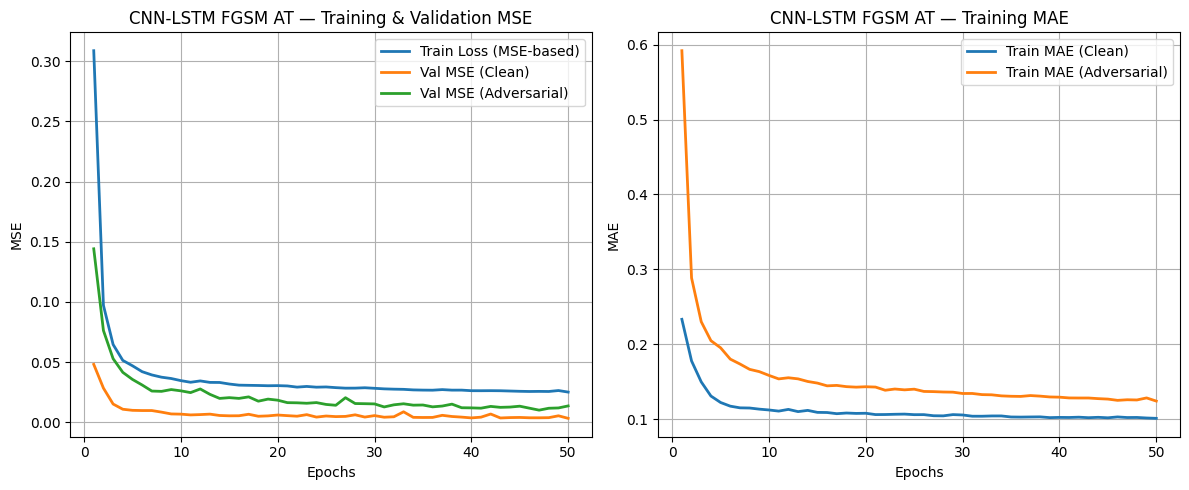

Saved FGSM adversarial training curves to:
/content/drive/MyDrive/Final Year Project/CNN_LSTM_FGSM_AT_training_curves_3.png


In [18]:
import matplotlib.pyplot as plt

# Number of epochs actually completed
epochs_ran = len(train_loss_hist)
epochs_axis = range(1, epochs_ran + 1)

plt.figure(figsize=(12, 5))

# ================= MSE Plot =================
plt.subplot(1, 2, 1)
plt.plot(epochs_axis, train_loss_hist, label="Train Loss (MSE-based)", linewidth=2)
plt.plot(epochs_axis, val_mse_clean_hist, label="Val MSE (Clean)", linewidth=2)
plt.plot(epochs_axis, val_mse_adv_hist, label="Val MSE (Adversarial)", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("CNN-LSTM FGSM AT — Training & Validation MSE")
plt.legend()
plt.grid(True)


# ================= MAE Plot =================
plt.subplot(1, 2, 2)
plt.plot(epochs_axis, train_mae_clean_hist, label="Train MAE (Clean)", linewidth=2)
plt.plot(epochs_axis, train_mae_adv_hist, label="Train MAE (Adversarial)", linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.title("CNN-LSTM FGSM AT — Training MAE")
plt.legend()
plt.grid(True)


plt.tight_layout()

# Save high-resolution figure
save_path = "/content/drive/MyDrive/Final Year Project/CNN_LSTM_FGSM_AT_training_curves_3.png"
plt.savefig(save_path, dpi=300)

plt.show()

print(f"Saved FGSM adversarial training curves to:\n{save_path}")
